# Tree-based models

**ELEC-E8739 - AI in health technologies**

Aleksei Tiulpin, PhD

In this tutorial, you will

* **Master** the theoretical underpinnings of decision tree algorithms and see how they can easily be modified
* **Train** the implemented models on toy data

## Imports & utilities

In [ ]:
import numpy as np
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# Visualize decision boundary
def plot_decision_boundary(X, y, model, title, figsize=(5, 5), dpi=150):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=figsize, dpi=dpi)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

    # Plot the training points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis',
                         edgecolor='black', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.colorbar(scatter, ticks=[0, 1, 2])
    plt.show()

## Useful tree-related functions

In [ ]:
class Node:
    """A node in the decision tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

def gini(y):
    """Calculates the Gini impurity for a set of labels."""
    hist = np.bincount(y)
    ps = hist / len(y)
    return 1 - np.sum([p**2 for p in ps if p > 0])


def purity_gain(X_column, y,  thr, impurity):
    parent_impurity = impurity(y)

    left_idxs = np.argwhere(X_column <= thr).flatten()
    right_idxs = np.argwhere(X_column > thr).flatten()

    if len(left_idxs) == 0 or len(right_idxs) == 0:
        return 0

    n = len(y)
    n_l, n_r = len(left_idxs), len(right_idxs)
    imp_l, imp_r = impurity(y[left_idxs]), impurity(y[right_idxs])

    impurity_split = (n_l / n) * imp_l + (n_r / n) * imp_r

    return parent_impurity - impurity_split

def variance(y):
    if len(y) == 0:
        return 0
    return np.var(y)

def best_split(X, y, impurity):
    best_gain = -1
    split_idx, split_thresh = None, None

    if impurity == "gini":
        impurity = gini
    elif impurity == "variance":
        impurity = variance
    else:
        raise ValueError("Unknown impurity function")

    for feat_idx in range(X.shape[1]):
        X_column = X[:, feat_idx]
        thresholds = np.unique(X_column)
        for thr in thresholds:
            # Fixed: correct argument order
            gain = purity_gain(X_column, y, thr, impurity)

            if gain > best_gain:
                best_gain = gain
                split_idx = feat_idx
                split_thresh = thr
    return split_idx, split_thresh

In [ ]:
class CARTBaseClass:
    """A from-scratch CART Decision Tree"""
    def __init__(self, min_samples_split=2, max_depth=3, split="gini"):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None
        self.split = split

    def fit(self, X, y):
        """Builds the decision tree."""
        self.root = self._grow_tree(X, y)

    def _vote(self, y):
        raise NotImplementedError("Voting is not implemented for the base class")

    def _grow_tree(self, X, y, depth=0):
        """Recursively grows the tree."""
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # 1. Check the stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._vote(y)
            return Node(value=leaf_value)

        # 2. Find the best split by searching through all features
        best_feature, best_thresh = best_split(X, y, self.split)

        # If no split provides gain, create a leaf node
        if best_feature is None:
            leaf_value = self._vote(y)
            return Node(value=leaf_value)

        # 3. Create child nodes
        left_idxs = np.argwhere(X[:, best_feature] <= best_thresh).flatten()
        right_idxs = np.argwhere(X[:, best_feature] > best_thresh).flatten()

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feature, best_thresh, left, right)

    def predict(self, X):
        """Predicts the class for an array of samples."""
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """Traverses the tree to find the prediction for a single sample."""
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [ ]:
class DecisionTree(CARTBaseClass):
    def __init__(self, min_samples_split=2, max_depth=3):
        super().__init__(min_samples_split, max_depth, split="gini")

    def _vote(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

### Ideal case

Classification Accuracy: 1.000


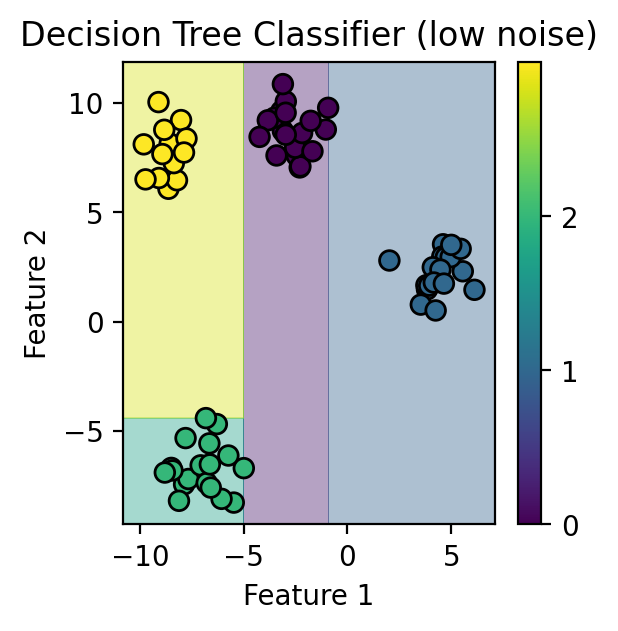

In [ ]:
np.random.seed(42)
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the decision tree
clf = DecisionTree(min_samples_split=5, max_depth=4)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Classification Accuracy: {accuracy:.3f}")

plot_decision_boundary(X_train, y_train, clf, 'Decision Tree Classifier (low noise)', figsize=(3, 3), dpi=200)

### Overfitting

Classification Accuracy: 0.700


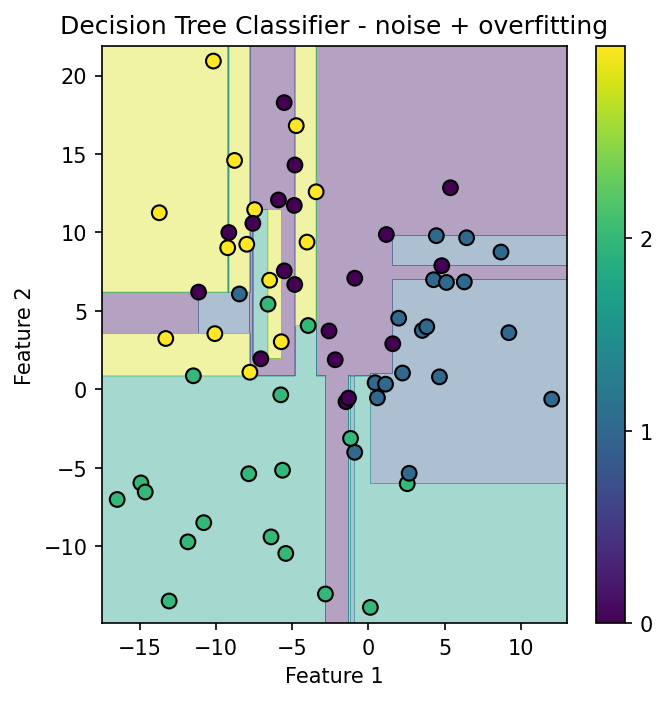

In [ ]:
np.random.seed(42)
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=5.0, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the decision tree
clf = DecisionTree(min_samples_split=2, max_depth=10)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Classification Accuracy: {accuracy:.3f}")

plot_decision_boundary(X_train, y_train, clf,
                       'Decision Tree Classifier - noise + overfitting')

Classification Accuracy: 0.700


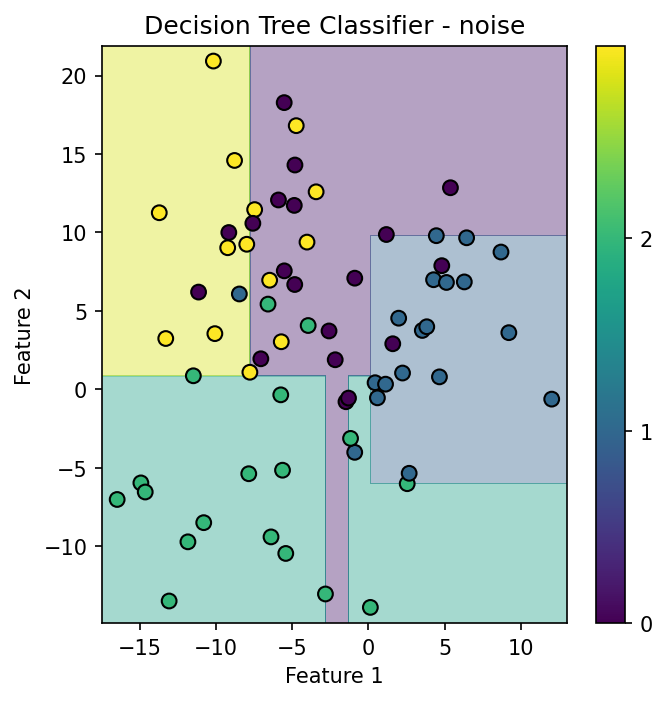

In [ ]:
np.random.seed(42)
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=5.0, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the decision tree
clf = DecisionTree(min_samples_split=5, max_depth=4)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Classification Accuracy: {accuracy:.3f}")

plot_decision_boundary(X_train, y_train, clf,
                       'Decision Tree Classifier - noise')

## Regression

In [ ]:
class RegressionTree(CARTBaseClass):
    def __init__(self, min_samples_split=2, max_depth=3):
        super().__init__(min_samples_split, max_depth, split="variance")

    def _vote(self, y):
        return np.mean(y)

In [ ]:
# Generate sinusoidal data with noise
n_samples = 100
X_sin = np.sort(5 * np.random.rand(n_samples, 1), axis=0)
y_sin = np.sin(X_sin).ravel() + np.random.normal(0, 0.1, n_samples)

X_test_sin = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

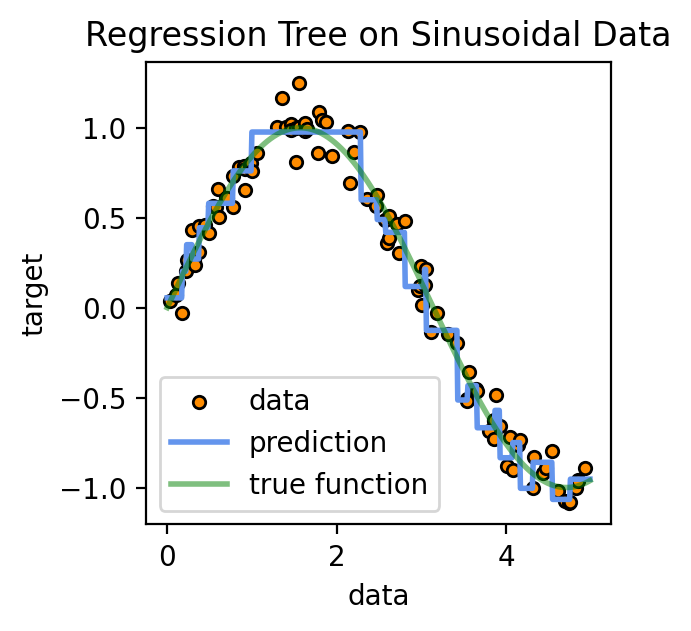

In [ ]:
reg_tree = RegressionTree(min_samples_split=5, max_depth=5)
reg_tree.fit(X_sin, y_sin)

# Make predictions

y_pred_sin = reg_tree.predict(X_test_sin)

# Visualize regression
plt.figure(figsize=(3, 3), dpi=200)
plt.scatter(X_sin, y_sin, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test_sin, y_pred_sin, color="cornflowerblue", label="prediction", linewidth=2)
plt.plot(X_test_sin, np.sin(X_test_sin), color="green", label="true function", linewidth=2, alpha=0.5)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Regression Tree on Sinusoidal Data")
plt.legend()
plt.show()


## Random Forest

In [ ]:
class BaseRandomForest:
    def __init__(self, n_trees=100, min_samples_split=2, max_depth=3, max_samples=0.8, n_features=None, seed=None):
        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.max_samples = max_samples
        assert max_samples <= 1, "max_samples must be <= 1"
        self.n_features = n_features
        self.trees = []
        self.features = []
        self.base_tree = None
        self.random_state = np.random.RandomState(seed)

    def fit(self, X, y):
        self.trees = []
        self.features = []  # Reset the features list

        # Set default n_features if not specified
        n_features = self.n_features
        if n_features is None:
            n_features = int(np.sqrt(X.shape[1]))

        for _ in range(self.n_trees):
            tree = self.base_tree(min_samples_split=self.min_samples_split, max_depth=self.max_depth)
            ind_samples = self.random_state.choice(X.shape[0], int(self.max_samples*X.shape[0]), replace=True)
            ind_features = self.random_state.choice(X.shape[1], n_features, replace=False)

            tree.fit(X[ind_samples][:, ind_features], y[ind_samples])
            self.trees.append(tree)
            self.features.append(ind_features)

    def _vote(self, y):
        raise NotImplementedError("Voting is not implemented for the base class")

    def predict(self, X):
        tree_preds = []
        for tree, features in zip(self.trees, self.features):
            tree_preds.append(tree.predict(X[:, features]))

        tree_preds = np.array(tree_preds)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        y_pred = np.array([self._vote(pred) for pred in tree_preds])
        return y_pred


In [ ]:
class RandomForestClassifier(BaseRandomForest):
    def __init__(self, n_trees=100, min_samples_split=2, max_depth=3, max_samples=0.8, n_features=None, seed=None):
        super().__init__(n_trees, min_samples_split, max_depth,  max_samples, n_features, seed)

        self.base_tree = DecisionTree

    def fit(self, X, y):
        if self.n_features is None:
            self.n_features = int(np.sqrt(X.shape[1]))
        return super().fit(X, y)

    def _vote(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

In [ ]:
np.random.seed(42)
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=3.0, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the decision tree
clf = RandomForestClassifier(n_trees=10, min_samples_split=3, max_depth=3, max_samples=0.2, n_features=2, seed=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Classification Accuracy: {accuracy:.3f}")


Classification Accuracy: 0.867


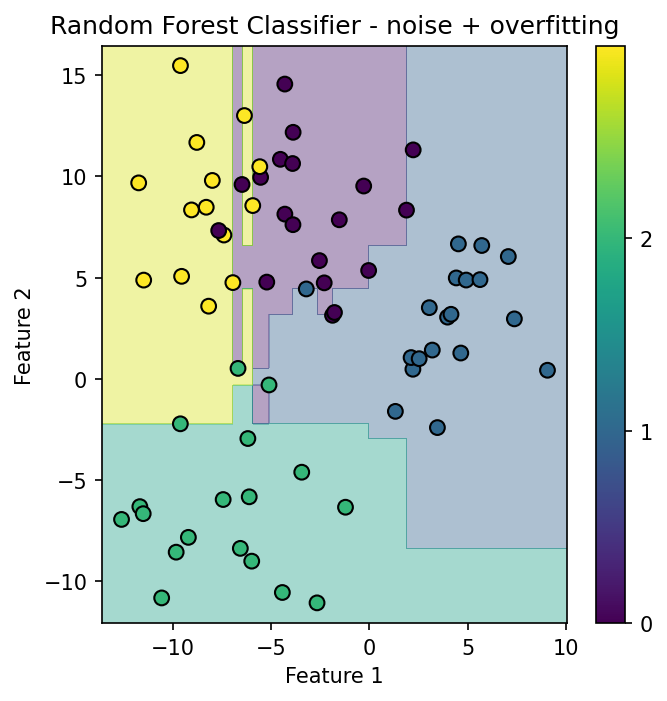

In [ ]:
plot_decision_boundary(X_train, y_train, clf,
                       'Random Forest Classifier - noise + overfitting')

## Random Forest regression

In [ ]:
class RandomForestRegressor(BaseRandomForest):
    def __init__(self, n_trees=100, min_samples_split=2, max_depth=3, max_samples=0.8, n_features=None, seed=None):
        super().__init__(n_trees, min_samples_split, max_depth,  max_samples, n_features, seed)

        self.base_tree = RegressionTree

    def fit(self, X, y):
        if self.n_features is None:
            self.n_features = X.shape[1] // 3
        return super().fit(X, y)

    def _vote(self, y):
        return y.mean()

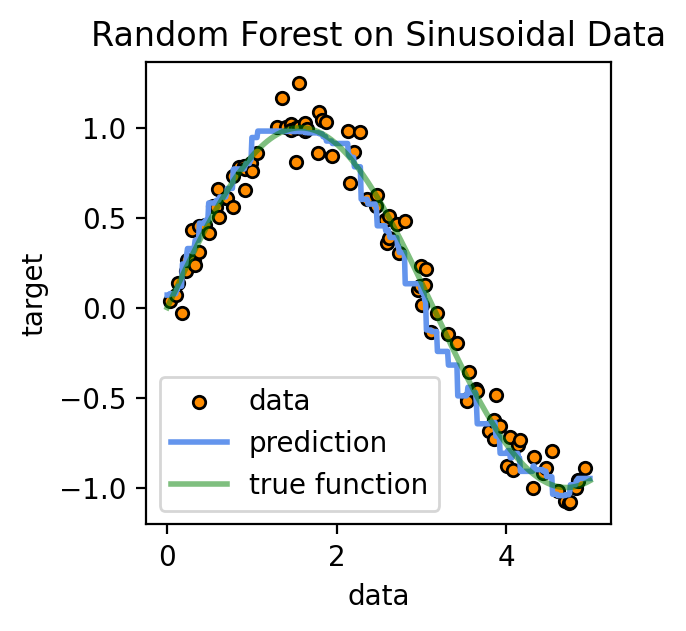

In [ ]:
reg_tree = RandomForestRegressor(n_trees=100, min_samples_split=5, max_depth=5, max_samples=0.8, n_features=1)
reg_tree.fit(X_sin, y_sin)

# Make predictions

y_pred_sin = reg_tree.predict(X_test_sin)

# Visualize regression
plt.figure(figsize=(3, 3), dpi=200)
plt.scatter(X_sin, y_sin, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test_sin, y_pred_sin, color="cornflowerblue", label="prediction", linewidth=2)
plt.plot(X_test_sin, np.sin(X_test_sin), color="green", label="true function", linewidth=2, alpha=0.5)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Random Forest on Sinusoidal Data")
plt.legend()
plt.show()